In [6]:

import glob
from tqdm.notebook import tqdm
import xarray as xr
import numpy as np
from dask.diagnostics import ProgressBar

year = 2014
target_resolution = 1.0

files = sorted(glob.glob(f'/Datastorage/saptarishi.dhanuka_asp25/imerg_data/*3IMERG.{year}*.nc4'))

combined_year = None  # Initialize the combined_year dataset

In [7]:
files

['/Datastorage/saptarishi.dhanuka_asp25/imerg_data/3B-DAY.MS.MRG.3IMERG.20140101-S000000-E235959.V07B.nc4',
 '/Datastorage/saptarishi.dhanuka_asp25/imerg_data/3B-DAY.MS.MRG.3IMERG.20140102-S000000-E235959.V07B.nc4',
 '/Datastorage/saptarishi.dhanuka_asp25/imerg_data/3B-DAY.MS.MRG.3IMERG.20140103-S000000-E235959.V07B.nc4',
 '/Datastorage/saptarishi.dhanuka_asp25/imerg_data/3B-DAY.MS.MRG.3IMERG.20140104-S000000-E235959.V07B.nc4',
 '/Datastorage/saptarishi.dhanuka_asp25/imerg_data/3B-DAY.MS.MRG.3IMERG.20140105-S000000-E235959.V07B.nc4',
 '/Datastorage/saptarishi.dhanuka_asp25/imerg_data/3B-DAY.MS.MRG.3IMERG.20140106-S000000-E235959.V07B.nc4',
 '/Datastorage/saptarishi.dhanuka_asp25/imerg_data/3B-DAY.MS.MRG.3IMERG.20140107-S000000-E235959.V07B.nc4',
 '/Datastorage/saptarishi.dhanuka_asp25/imerg_data/3B-DAY.MS.MRG.3IMERG.20140108-S000000-E235959.V07B.nc4',
 '/Datastorage/saptarishi.dhanuka_asp25/imerg_data/3B-DAY.MS.MRG.3IMERG.20140109-S000000-E235959.V07B.nc4',
 '/Datastorage/saptarishi.dh

In [8]:
for i, fname in enumerate(tqdm(files)):
    try:
        ds = xr.open_dataset(fname)
        old_lats = ds['lat'].values
        old_lons = ds['lon'].values
        new_lats = np.arange(-90.0, 90.0 + 1e-8, target_resolution)
        new_lats = np.flip(new_lats)
        new_lons = np.arange(-180.0, 180.0 + 1e-8, target_resolution)
        ds_interp = ds.interp({'lat': new_lats, 'lon': new_lons}, 
                                method='linear',
                                kwargs={'fill_value': None})
    except OSError as ose:
        print(f"Error opening file {fname}: {ose}")
        continue
    try:
        ds_subset = ds_interp[['precipitation', 'randomError']]
    except KeyError as ke:
        raise KeyError(f"File {fname} is missing one of the required variables: {ke}")
    
    if combined_year is None:
        combined_year = ds_subset
    else:
        combined_year = xr.concat([combined_year, ds_subset], dim='time')

  0%|          | 0/365 [00:00<?, ?it/s]

In [9]:
combined_year

<xarray.Dataset> Size: 382MB
Dimensions:        (time: 365, lon: 361, lat: 181)
Coordinates:
  * time           (time) datetime64[ns] 3kB 2014-01-01 ... 2014-12-31
  * lat            (lat) float64 1kB 90.0 89.0 88.0 87.0 ... -88.0 -89.0 -90.0
  * lon            (lon) float64 3kB -180.0 -179.0 -178.0 ... 178.0 179.0 180.0
Data variables:
    precipitation  (time, lon, lat) float64 191MB nan nan nan ... nan nan nan
    randomError    (time, lon, lat) float64 191MB nan nan nan ... nan nan nan
Attributes:
    BeginDate:       2014-01-01
    BeginTime:       00:00:00.000Z
    EndDate:         2014-01-01
    EndTime:         23:59:59.999Z
    FileHeader:      StartGranuleDateTime=2014-01-01T00:00:00.000Z;\nStopGran...
    InputPointer:    3B-HHR.MS.MRG.3IMERG.20140101-S000000-E002959.0000.V07B....
    title:           GPM IMERG Final Precipitation L3 1 day 0.1 degree x 0.1 ...
    DOI:             10.5067/GPM/IMERGDF/DAY/07
    ProductionTime:  2024-01-12T13:09:09.320Z

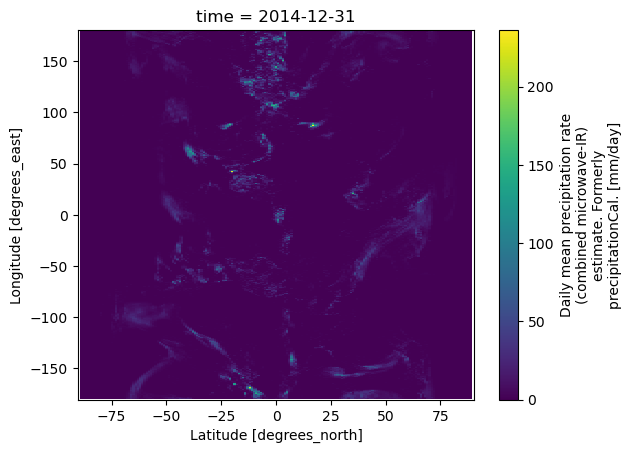

In [13]:
combined_year.isel(time=-1)['precipitation'].plot()

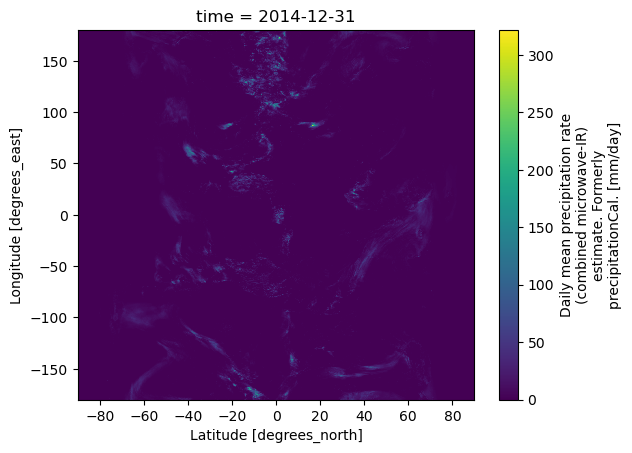

In [12]:
ds.isel(time=0)['precipitation'].plot()

In [5]:
test = xr.open_dataset('/Datastorage/saptarishi.dhanuka_asp25/imerg_data/3B-DAY.MS.MRG.3IMERG.20250129-S000000-E235959.V07B.nc4')
print(test)

<xarray.Dataset> Size: 117MB
Dimensions:                         (time: 1, lon: 3600, lat: 1800, nv: 2)
Coordinates:
  * lon                             (lon) float32 14kB -179.9 -179.9 ... 179.9
  * lat                             (lat) float64 14kB -89.95 -89.85 ... 89.95
  * time                            (time) datetime64[ns] 8B 2025-01-29
Dimensions without coordinates: nv
Data variables:
    precipitation                   (time, lon, lat) float32 26MB ...
    precipitation_cnt               (time, lon, lat) int8 6MB ...
    precipitation_cnt_cond          (time, lon, lat) int8 6MB ...
    MWprecipitation                 (time, lon, lat) float32 26MB ...
    MWprecipitation_cnt             (time, lon, lat) int8 6MB ...
    MWprecipitation_cnt_cond        (time, lon, lat) int8 6MB ...
    randomError                     (time, lon, lat) float32 26MB ...
    randomError_cnt                 (time, lon, lat) int8 6MB ...
    probabilityLiquidPrecipitation  (time, lon, lat) int8 6MB 

In [ ]:
test = xr.open_dataset('/Datastorage/saptarishi.dhanuka_asp25/imerg30min/3B-HHR.MS.MRG.3IMERG.20140602-S043000-E045959.0270.V07B.nc')
print(test)

<xarray.Dataset> Size: 2MB
Dimensions:                    (time: 1, lon: 338, lat: 295)
Coordinates:
  * time                       (time) datetime64[ns] 8B 2015-06-30T18:30:00
  * lon                        (lon) float32 1kB 65.05 65.15 ... 98.65 98.75
  * lat                        (lat) float32 1kB 5.75 5.85 5.95 ... 35.05 35.15
Data variables:
    MWobservationTime          (time, lon, lat) timedelta64[ns] 798kB ...
    precipitation              (time, lon, lat) float32 399kB ...
    randomError                (time, lon, lat) float32 399kB ...
    precipitationQualityIndex  (time, lon, lat) float32 399kB ...
Attributes:
    CDI:                                    Climate Data Interface version 1....
    Conventions:                            CF-1.6
    Original_Producer_Metadata_FileHeader:  DOI=10.5067/GPM/IMERG/3B-HH/07;\n...
    Original_Producer_Metadata_FileInfo:    DataFormatVersion=7e;\nTKCodeBuil...
    Original_Producer_Metadata_GridHeader:  BinMethod=ARITHMETIC_MEAN;\n

/tmp/ipykernel_368859/1530681998.py:1: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  test = xr.open_dataset('/Datastorage/saptarishi.dhanuka_asp25/imerg30min/3B-HHR.MS.MRG.3IMERG.20150630-S183000-E185959.1110.V07B.HDF5.SUB.nc4')


In [90]:
import os
import glob
import xarray as xr
import matplotlib.pyplot as plt
import imageio
from tqdm import tqdm
import numpy as np

def make_precip_gif(
    nc_dir, 
    gif_path="imerg_precip.gif", 
    india=True, 
    duration=0.5
):
    """
    Creates a GIF of precipitation data from IMERG .nc4 files without using cartopy.

    Parameters
    ----------
    nc_dir : str
        Directory containing .nc4 files.
    gif_path : str
        Output path for GIF.
    india : bool
        If True, subset to India region. Otherwise plot global.
    duration : float
        Duration (seconds) per frame in GIF.
    """
    nc_files = sorted(glob.glob(os.path.join(nc_dir, "*.nc")))[:50]
    print(f"Found {len(nc_files)} files")
    if not nc_files:
        raise FileNotFoundError(f"No .nc files found in {nc_dir}")
    
    # Directory for temporary PNGs
    png_dir = os.path.join(nc_dir, "plots")
    os.makedirs(png_dir, exist_ok=True)
    png_files = []

    # India bounding box (lon_min, lon_max, lat_min, lat_max)
    india_bounds = [68, 98, 6, 38]

    for i, f in tqdm(enumerate(nc_files), total=len(nc_files)):
        ds = xr.open_dataset(f)
        
        if "precipitation" not in ds:
            raise KeyError(f"'precipitation' not found in {f}")
        
        precip = ds["precipitation"].squeeze()
        lat = ds["lat"].values
        lon = ds["lon"].values

        # Subset to India if required
        if india:
            lat_mask = (lat >= india_bounds[2]) & (lat <= india_bounds[3])
            lon_mask = (lon >= india_bounds[0]) & (lon <= india_bounds[1])
            precip = precip[..., lat_mask, :][:, :, lon_mask]
            lat = lat[lat_mask]
            lon = lon[lon_mask]

        # Plot using plain matplotlib
# Plot using plain matplotlib
        plt.figure(figsize=(10, 6))
        plt.imshow(
            precip.values, 
            origin="lower", 
            extent=[lon.min(), lon.max(), lat.min(), lat.max()], 
            cmap="Blues", 
            aspect="auto"
        )
        plt.colorbar(label="Precipitation (mm/hr)")

        # Safe time handling
        if "time" in precip.coords:
            time_str = str(precip.time.values)
        else:
            time_str = os.path.basename(f)
        plt.title(f"IMERG Precipitation\n{time_str}")

        plt.xlabel("Longitude")
        plt.ylabel("Latitude")


        png_file = os.path.join(png_dir, f"frame_{i:03d}.png")
        plt.savefig(png_file, dpi=150, bbox_inches="tight")
        plt.close()
        png_files.append(png_file)
        ds.close()

    # Make GIF
    with imageio.get_writer(gif_path, mode="I", duration=duration) as writer:
        for filename in png_files:
            writer.append_data(imageio.imread(filename))

    print(f"GIF saved at {gif_path}")


Found 50 files


  0%|          | 0/50 [00:00<?, ?it/s]


KeyboardInterrupt: 

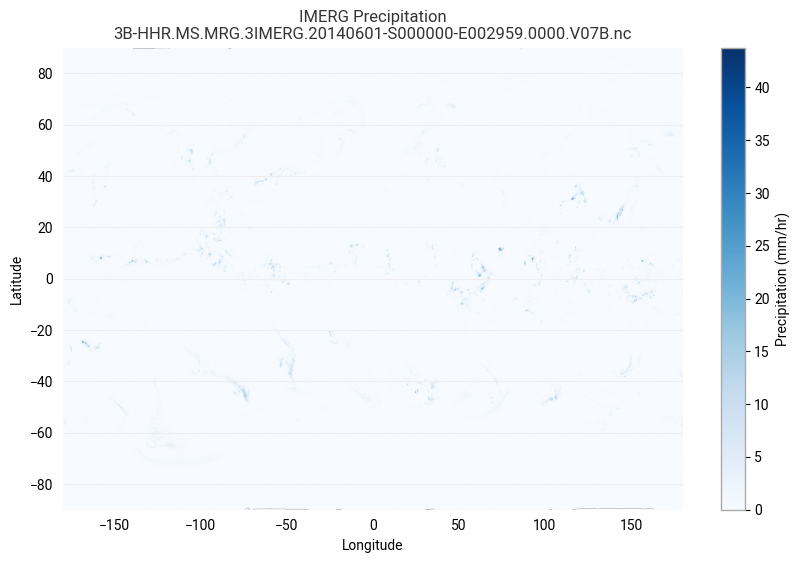

In [93]:
make_precip_gif(
    nc_dir="/Datastorage/saptarishi.dhanuka_asp25/imerg30min",
    gif_path="imerg_precip.gif",
    india=False,
    duration=0.5
)

In [1]:
import h5py
import netCDF4 as nc
import numpy as np
import glob
import os



In [3]:

count_negatives = 0

def copy_attributes(in_object, out_object):
    """Copy attributes from input object to output object, excluding problematic attributes"""
    skip_attributes = {
        '_FillValue',
        'DIMENSION_LIST',
        'REFERENCE_LIST',
        'CLASS',
        'NAME'
    }
    
    for key, value in in_object.attrs.items():
        if key not in skip_attributes:
            try:
                out_object.setncattr(key, value)
            except Exception as e:
                print(f"Info: Skipping attribute {key}")

def get_india_indices(grid, lat_min=6, lat_max=38, lon_min=68, lon_max=98):
    """
    Determine the indices for latitudes and longitudes that fall within India.
    Adjust the boundaries (lat_min, lat_max, lon_min, lon_max) as needed.
    """
    full_lat = grid['lat'][:]
    full_lon = grid['lon'][:]

    
    # Find indices where the latitudes and longitudes fall in the desired range.
    lat_inds = np.where((full_lat >= lat_min) & (full_lat <= lat_max))[0]
    lon_inds = np.where((full_lon >= lon_min) & (full_lon <= lon_max))[0]
    
    return lat_inds, lon_inds

def create_dimensions(nc_file, grid, lat_inds, lon_inds):
    """Create dimensions based on the subset of the IMERG data corresponding to India"""
    # Create time dimension (unchanged)
    time_data = grid['time'][:]
    nc_file.createDimension('time', len(time_data))
    
    # Create lat and lon dimensions using the subset indices
    nc_file.createDimension('lat', len(lat_inds))
    nc_file.createDimension('lon', len(lon_inds))
    
    # Create bounds dimension (usually fixed as 2)
    nc_file.createDimension('nv', 2)

def create_coordinate_variables(nc_file, grid, lat_inds, lon_inds):
    """Create coordinate variables using the subset of latitudes and longitudes"""
    # Time variable (unchanged)
    time_var = nc_file.createVariable('time', np.float64, ('time',))
    time_var[:] = grid['time'][:]
    copy_attributes(grid['time'], time_var)
    
    # Latitude variable subset
    full_lat = grid['lat'][:]
    subset_lat = full_lat[lat_inds]
    lat_var = nc_file.createVariable('lat', np.float32, ('lat',))
    lat_var[:] = subset_lat
    copy_attributes(grid['lat'], lat_var)
    
    # Longitude variable subset
    full_lon = grid['lon'][:]
    subset_lon = full_lon[lon_inds]
    lon_var = nc_file.createVariable('lon', np.float32, ('lon',))
    lon_var[:] = subset_lon
    copy_attributes(grid['lon'], lon_var)
    
    # Bounds variables: subset the bounds if needed
    # (Assuming grid['lat_bnds'] and grid['lon_bnds'] are 2D arrays with shape (n, 2))
    lat_bnds_full = grid['lat_bnds'][:]
    subset_lat_bnds = lat_bnds_full[lat_inds, :]
    lat_bnds = nc_file.createVariable('lat_bnds', np.float32, ('lat', 'nv'))
    lat_bnds[:] = subset_lat_bnds
    
    lon_bnds_full = grid['lon_bnds'][:]
    subset_lon_bnds = lon_bnds_full[lon_inds, :]
    lon_bnds = nc_file.createVariable('lon_bnds', np.float32, ('lon', 'nv'))
    lon_bnds[:] = subset_lon_bnds

def create_data_variables(nc_file, grid, lat_inds, lon_inds):
    """Create data variables (e.g., precipitation) using the subset of lat/lon indices"""
    # List of main variable names to process
    var_names = ['precipitation']
    
    for var_name in var_names:
        if var_name in grid:
            try:
                var_data = grid[var_name][:]

                # Assuming var_data has dimensions (time, lon, lat),
                # we subset the 2nd (lon) and 3rd (lat) dimensions.
                # (If the dimensions are different, adjust the slicing accordingly.)
                subset_var_data = var_data[:, lon_inds, :][:, :, lat_inds]
                # print(subset_var_data)

                negatives = np.sum(subset_var_data < 0)
                global count_negatives
                if negatives != 0:
                    count_negatives += 1



                # Create the variable in the NetCDF file
                var = nc_file.createVariable(var_name, var_data.dtype, ('time', 'lon', 'lat'))
                var[:] = subset_var_data
                copy_attributes(grid[var_name], var)
            except Exception as e:
                print(f"Warning: Error processing {var_name}: {e}")

def convert_h5_to_nc(h5_path, nc_path, lat_min=6, lat_max=38, lon_min=68, lon_max=98, india=False):
    if india==False:
        lat_min = -90
        lat_max = 90
        lon_min = -180
        lon_max = 180
    """Convert IMERG HDF5 file to NetCDF4 with only data for India"""
    if os.path.exists(nc_path):
        return
    with h5py.File(h5_path, 'r') as h5_file:
        with nc.Dataset(nc_path, 'w', format='NETCDF4') as nc_file:
            # Copy global attributes
            copy_attributes(h5_file, nc_file)
            
            grid = h5_file['Grid']
            
            # Get the indices corresponding to India's bounding box
            lat_inds, lon_inds = get_india_indices(grid, lat_min, lat_max, lon_min, lon_max)
            if len(lat_inds) == 0 or len(lon_inds) == 0:
                raise ValueError("No latitude or longitude values found within the specified India bounds.")
            
            # Create dimensions using the subset indices
            create_dimensions(nc_file, grid, lat_inds, lon_inds)
            # Create coordinate variables (time, lat, lon, bounds)
            create_coordinate_variables(nc_file, grid, lat_inds, lon_inds)
            # Create the data variables (e.g., precipitation)
            create_data_variables(nc_file, grid, lat_inds, lon_inds)


files = glob.glob('./*.HDF5')
files

['./3B-HHR.MS.MRG.3IMERG.20140601-S000000-E002959.0000.V07B.HDF5']

In [ ]:
print(files[0])
count = 0
for file in files:
    # if the file with the same name but with .nc extension already exists, skip it
    count += 1
    print(count, end='\n\n')
    try:
        convert_h5_to_nc(file, file.replace('HDF5', 'nc'), india=False)
    except OSError as e:
        with open("conversion_errors.txt", "a") as f:
            f.write(f"Error converting {file}: {e}\n")
        continue
print(count_negatives)

In [12]:
year = 2015
files30min = sorted(glob.glob(f'/Datastorage/saptarishi.dhanuka_asp25/imerg30min/*3IMERG.{year}*.HDF5*'))
files30min

['/Datastorage/saptarishi.dhanuka_asp25/imerg30min/3B-HHR.MS.MRG.3IMERG.20150601-S000000-E002959.0000.V07B.HDF5.SUB.nc4',
 '/Datastorage/saptarishi.dhanuka_asp25/imerg30min/3B-HHR.MS.MRG.3IMERG.20150601-S003000-E005959.0030.V07B.HDF5.SUB.nc4',
 '/Datastorage/saptarishi.dhanuka_asp25/imerg30min/3B-HHR.MS.MRG.3IMERG.20150601-S010000-E012959.0060.V07B.HDF5.SUB.nc4',
 '/Datastorage/saptarishi.dhanuka_asp25/imerg30min/3B-HHR.MS.MRG.3IMERG.20150601-S013000-E015959.0090.V07B.HDF5.SUB.nc4',
 '/Datastorage/saptarishi.dhanuka_asp25/imerg30min/3B-HHR.MS.MRG.3IMERG.20150601-S020000-E022959.0120.V07B.HDF5.SUB.nc4',
 '/Datastorage/saptarishi.dhanuka_asp25/imerg30min/3B-HHR.MS.MRG.3IMERG.20150601-S023000-E025959.0150.V07B.HDF5.SUB.nc4',
 '/Datastorage/saptarishi.dhanuka_asp25/imerg30min/3B-HHR.MS.MRG.3IMERG.20150601-S030000-E032959.0180.V07B.HDF5.SUB.nc4',
 '/Datastorage/saptarishi.dhanuka_asp25/imerg30min/3B-HHR.MS.MRG.3IMERG.20150601-S033000-E035959.0210.V07B.HDF5.SUB.nc4',
 '/Datastorage/saptarish

In [13]:
import numpy as np
import h5py
import matplotlib.pyplot as plt

# 1. Download your IMERG HDF5 file manually or via script; for example:
#    https://arthurhou.pps.eosdis.nasa.gov/gpmdata/2021/05/19/3B-HHR.MS.MRG.3IMERG.20210519-S000000-E002959.0000.V06B.HDF5
file = files30min[-1]

# 2. Read the file
data = h5py.File(file, 'r')
data

<HDF5 file "3B-HHR.MS.MRG.3IMERG.20151231-S233000-E235959.1410.V07B.HDF5.SUB.nc4" (mode r)>

In [15]:
dir(data)

['_MutableMapping__marker',
 '__abstractmethods__',
 '__bool__',
 '__class__',
 '__class_getitem__',
 '__contains__',
 '__delattr__',
 '__delitem__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__enter__',
 '__eq__',
 '__exit__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getitem__',
 '__getnewargs__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__iter__',
 '__le__',
 '__len__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__nonzero__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__reversed__',
 '__setattr__',
 '__setitem__',
 '__sizeof__',
 '__slots__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_abc_impl',
 '_d',
 '_e',
 '_gcpl_crt_order',
 '_id',
 '_in_memory_file_counter',
 '_ipython_key_completions_',
 '_lapl',
 '_lcpl',
 '_libver',
 'attrs',
 'build_virtual_dataset',
 'clear',
 'close',
 'copy',
 'create_dataset',
 'create_dataset_like',
 'create_group',
 'create_virtual_dataset',
 'driver',
 'file',
 'filename',
 'flush',
 '

In [14]:
data['Grid'].values()

KeyError: "Unable to synchronously open object (object 'Grid' doesn't exist)"

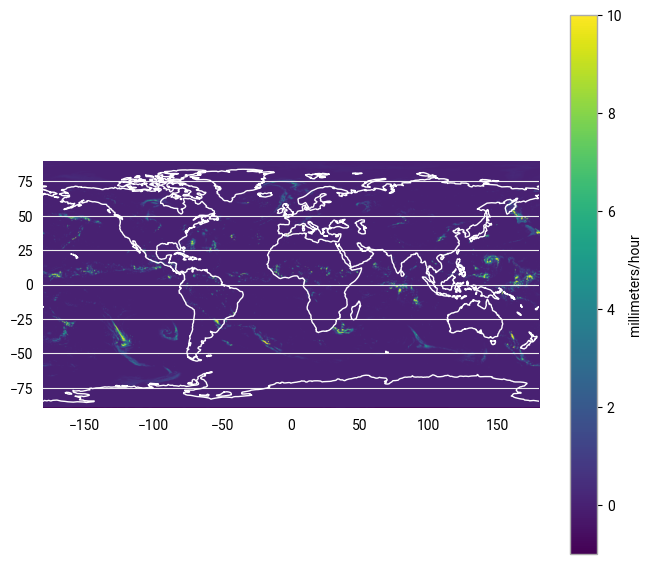

In [51]:
data = h5py.File(file,'r')

# -- extract the 3600x1800 element precipitation array.
# For Version 6 IMERG HDF5 files, read the "precipitationCal"
# variable if it is a half-hour file and the "precipitation"
# variable if it is a monthly file.  For Version 7, the variable
# is "precipitation" for both durations.
precip = data['/Grid/precipitation'][:]

# -- get rid of the dummy single-element first dimension,
# transpose to get longitude on the x axis, and flip vertically
# so that latitude is displayed south to north as it should be
precip = np.flip( precip[0,:,:].transpose(), axis=0 )

# -- display the precipitation data. Regions with missing data
# values have negative values in the precip variable so allow
# the color table to extend to negative values.
import matplotlib.pyplot as plt
plt.imshow( precip, vmin=-1, vmax=10, extent=[-180,180,-90,90] )

# -- add a color bar
cbar = plt.colorbar( )
cbar.set_label('millimeters/hour')

# # -- display lat/lon grid lines
# for lon in np.arange(-90,90+1,90):
#   dummy = plt.plot( (lon,lon), (-90,+90), color="black", linewidth=1 )

# for lat in np.arange(-60,60+1,30):
#   dummy = plt.plot( (-180,+180), (lat,lat), color="black", linewidth=1 )

# -- display the optional coastline shapefile
import shapefile as shp
shapeID = shp.Reader( 'ne_110m_coastline.shp')
for shape in shapeID.shapeRecords():
  point = np.array( shape.shape.points )
  dummy = plt.plot( point[:,0] , point[:,1], color="white",
    linewidth=1 )

# -- save the image to disk and display on the screen
plt.savefig('imerg.png',dpi=200)
plt.show()

Grid keys: ['Intermediate', 'nv', 'lonv', 'latv', 'time', 'lon', 'lat', 'time_bnds', 'lon_bnds', 'lat_bnds', 'precipitation', 'randomError', 'probabilityLiquidPrecipitation', 'precipitationQualityIndex']
raw precip shape: (1, 3600, 1800)
Saved imerg_precip.nc


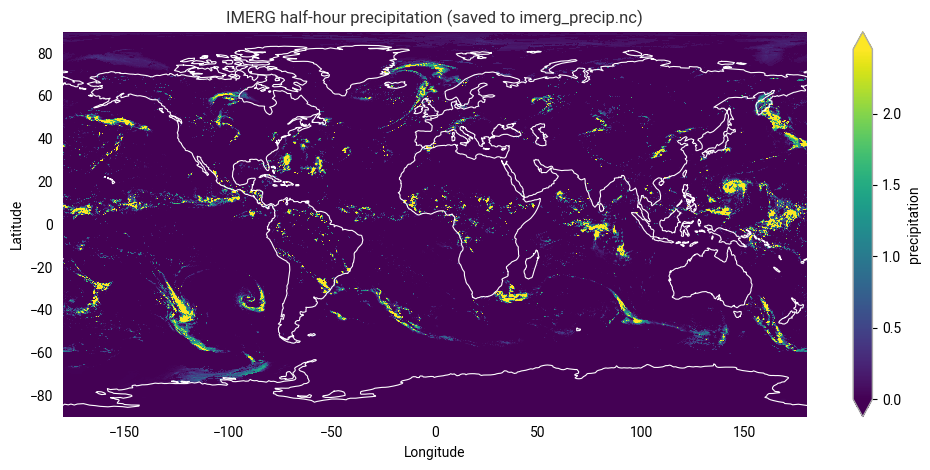

In [53]:
import h5py
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import shapefile as shp   # pyshp

file = files30min[-1]
shapefile_path = "ne_110m_coastline.shp"   # your shapefile

# -------------------------
#  read HDF5 and build xarray
# -------------------------
with h5py.File(file, "r") as f:
    grid = f["/Grid"]
    # list available keys (for debugging)
    print("Grid keys:", list(grid.keys()))

    # choose the precipitation variable robustly
    if "precipitation" in grid:
        pkey = "precipitation"
    elif "precipitationCal" in grid:
        pkey = "precipitationCal"
    else:
        raise KeyError("Neither 'precipitation' nor 'precipitationCal' found in /Grid")

    precip = grid[pkey][:]
    print("raw precip shape:", precip.shape)

    # get lon/lat from file if present, otherwise construct a 0.1° global grid
    if "lon" in grid and "lat" in grid:
        lon = grid["lon"][:]
        lat = grid["lat"][:]
    else:
        # IMERG nominal grid: 3600 x 1800 at 0.1° resolution
        nx = precip.shape[-1]
        ny = precip.shape[-2]
        lon = np.linspace(-179.95, 179.95, nx)   # centerpoints
        lat = np.linspace(89.95, -89.95, ny)     # often stored north->south in HDF

    # collapse the dummy leading dimension if present
    if precip.ndim == 3 and precip.shape[0] == 1:
        arr = precip[0, :, :]
    else:
        arr = precip

    # If lat is descending (north->south), xarray prefers coords increasing.
    # We'll make lat increasing and flip the data if needed.
    if lat[0] > lat[-1]:
        lat = lat[::-1]
        arr = arr[::-1, :]

# create xarray DataArray
da = xr.DataArray(
    arr.T,
    dims=("lat", "lon"),
    coords={"lat": lat, "lon": lon},
    name="precipitation"
)

# save to disk (xarray format: NetCDF)
da.to_dataset(name="precipitation").to_netcdf("imerg_precip_test.nc")
print("Saved imerg_precip.nc")

# -------------------------
#  plot with xarray and shapefile coastlines (no connecting lines)
# -------------------------
fig, ax = plt.subplots(figsize=(12, 5))

# xarray plotting (uses pcolormesh under the hood)
# you can use .plot or .plot.pcolormesh; set robust=True or vmin/vmax as desired
da.plot.pcolormesh(
    ax=ax,
    cmap="viridis",
    vmin=0.0,          # change as required
    vmax=np.nanpercentile(da.values, 99),
    add_colorbar=True
)

# overlay coastline shapefile, plotting each part separately to avoid connecting parts
sf = shp.Reader(shapefile_path)
for shapeRec in sf.shapeRecords():
    s = shapeRec.shape
    points = np.asarray(s.points)
    parts = list(s.parts) + [len(points)]
    for i in range(len(s.parts)):
        start = parts[i]
        end = parts[i + 1]
        seg = points[start:end]
        # avoid plotting degenerate segments
        if seg.shape[0] > 1:
            ax.plot(seg[:, 0], seg[:, 1], color="white", linewidth=0.8, zorder=2)

ax.set_title("IMERG half-hour precipitation (saved to imerg_precip.nc)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.savefig("imerg_xarray_plot.png", dpi=200, bbox_inches="tight")
plt.show()


In [4]:
files30min

NameError: name 'files30min' is not defined

In [10]:
import os
from pathlib import Path
import h5py
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# Optional: shapefile plotting (pyshp). If you don't want coastline overlay, set shapefile_path = None
try:
    import shapefile as shp   # pyshp
except Exception:
    shp = None

# CONFIG
files30min = files30min  # your existing list of HDF5 paths
out_dir = Path("/Datastorage/saptarishi.dhanuka_asp25/imerg30min")
plot_dir = Path("plots")
out_dir.mkdir(parents=True, exist_ok=True)
plot_dir.mkdir(parents=True, exist_ok=True)
shapefile_path = "ne_110m_coastline.shp"  # set to None to skip shapefile overlay
compress_level = 4

def process_hdf_to_nc_and_plot(hdf_path: Path, out_dir: Path, plot_dir: Path,
                               shapefile_path: str = None, compress_level: int = 4):
    #print(f"\nProcessing: {hdf_path.name}")

    out_name = out_dir / (hdf_path.stem + ".nc")
    if os.path.exists(out_name):
        return
        
    error_count = 0
    try:
        with h5py.File(hdf_path, "r") as f:
            if "/Grid" not in f:
                raise KeyError("/Grid group not found in file")
            grid = f["/Grid"]

            # detect precipitation variable
            if "precipitation" in grid:
                pkey = "precipitation"
            elif "precipitationCal" in grid:
                pkey = "precipitationCal"
            else:
                raise KeyError("Neither 'precipitation' nor 'precipitationCal' found in /Grid")

            precip = grid[pkey][:]
            #print("  raw precip shape:", precip.shape)

            # expected HDF shapes: (1, nlat, nlon) or (nlat, nlon) or sometimes (nlon, nlat)
            nlat_hdf = precip.shape[-1]
            nlon_hdf = precip.shape[-2]

            # collapse leading time-like dim if present
            if precip.ndim == 3 and precip.shape[0] == 1:
                arr = precip[0, :, :].astype(float).copy()
            else:
                arr = precip.astype(float).copy()

            #print("  arr.shape (after collapse if any):", arr.shape)

            # try to read lon/lat from HDF if present (common names)
            lon = None
            lat = None
            for name in ("lon", "longitude", "Lon", "LON"):
                if name in grid:
                    lon = grid[name][:]
                    break
            for name in ("lat", "latitude", "Lat", "LAT"):
                if name in grid:
                    lat = grid[name][:]
                    break

            # fallback to nominal IMERG 0.1° grid
            if lon is None or lat is None:
                nx = nlon_hdf
                ny = nlat_hdf
                lon = np.linspace(-179.95, 179.95, nx)
                lat = np.linspace(89.95, -89.95, ny)  # HDF often stores north->south

            lon = np.asarray(lon)
            lat = np.asarray(lat)
            #print("  lon/lat lengths:", len(lon), len(lat), "expected (nlon,nlat):", nlon_hdf, nlat_hdf)

            # Ensure arr is (nlat, nlon). If it's transposed, fix it.
            if arr.shape == (nlat_hdf, nlon_hdf):
                pass  # OK
            elif arr.shape == (nlon_hdf, nlat_hdf):
                #print("  detected transposed array -> transposing")
                arr = arr.T
            else:
                # maybe lon/lat were swapped; attempt to detect and swap lon/lat
                if arr.shape == (len(lon), len(lat)):
                    #print("  detected lon/lat were swapped; swapping lon/lat to match arr")
                    lon, lat = lat, lon
                    if arr.shape == (len(lat), len(lon)):
                        arr = arr.T

                if arr.shape != (len(lat), len(lon)):
                    raise ValueError(f"After checks, arr.shape {arr.shape} does not match (len(lat),len(lon)) = ({len(lat)},{len(lon)})")

            # xarray likes lat increasing (south->north); if lat is descending, flip arr vertically
            if lat[0] > lat[-1]:
                lat = lat[::-1]
                arr = arr[::-1, :]

            # mask negative values (IMERG uses negatives for missing)
            arr = np.where(arr < 0, np.nan, arr)

            # build DataArray
            da = xr.DataArray(
                arr,
                dims=("lat", "lon"),
                coords={"lat": lat, "lon": lon},
                name="precipitation",
                attrs={
                    "source_file": str(hdf_path),
                    "units": "mm/hr",
                }
            )

            # dataset
            ds = da.to_dataset()

            # encoding with compression
            enc = {
                "precipitation": {
                    "zlib": True,
                    "complevel": compress_level,
                    "dtype": "float32"
                }
            }

            # save NetCDF
            out_name = out_dir / (hdf_path.stem + ".nc")
            ds.to_netcdf(path=str(out_name), mode="w", format="NETCDF4", encoding=enc)
            #print(f"  saved NC -> {out_name}")

            # # --- create and save plot ---
            # fig, ax = plt.subplots(figsize=(12, 5))
            # # choose vmin/vmax robustly
            # try:
            #     vmax = float(np.nanpercentile(da.values, 99))
            # except Exception:
            #     vmax = np.nanmax(da.values)
            # vmin = 0.0

            # # pcolormesh via xarray plotting (rasterized helps keep file size manageable)
            # da.plot.pcolormesh(ax=ax, vmin=vmin, vmax=vmax, add_colorbar=True, rasterized=True)

            # # overlay coastline shapefile safely if requested and pyshp is available
            # if shapefile_path and shp is not None:
            #     try:
            #         sf = shp.Reader(shapefile_path)
            #         for shapeRec in sf.shapeRecords():
            #             s = shapeRec.shape
            #             pts = np.asarray(s.points)
            #             parts = list(s.parts) + [len(pts)]
            #             for i in range(len(s.parts)):
            #                 start = parts[i]
            #                 end = parts[i + 1]
            #                 seg = pts[start:end]
            #                 if seg.shape[0] > 1:
            #                     ax.plot(seg[:, 0], seg[:, 1], color="white", linewidth=0.8, zorder=2)
            #     except Exception as e:
            #         print("  warning: could not plot shapefile coastlines:", e)


            # ax.set_title(hdf_path.name)
            # ax.set_xlabel("Longitude")
            # ax.set_ylabel("Latitude")

            # plot_name = plot_dir / (hdf_path.stem + ".png")
            # fig.savefig(str(plot_name), dpi=200, bbox_inches="tight")
            # plt.close(fig)
            #print(f"  saved plot -> {plot_name}")

            return out_name, None

    except Exception as exc:
        #print(f"  ERROR processing {hdf_path.name}: {exc}")
        error_count +=1
        print(error_count, " errors till now", exc)
        return None, None

# Run conversion + plotting for all files
saved = []
for f in files30min:
    p = Path(f)
    nc_file, png_file = process_hdf_to_nc_and_plot(p, out_dir, plot_dir, shapefile_path=shapefile_path, compress_level=compress_level)
    saved.append((p, nc_file, png_file))


1  errors till now '/Grid group not found in file'
1  errors till now '/Grid group not found in file'
1  errors till now '/Grid group not found in file'
1  errors till now '/Grid group not found in file'
1  errors till now '/Grid group not found in file'
1  errors till now '/Grid group not found in file'
1  errors till now '/Grid group not found in file'
1  errors till now '/Grid group not found in file'
1  errors till now '/Grid group not found in file'
1  errors till now '/Grid group not found in file'
1  errors till now '/Grid group not found in file'
1  errors till now '/Grid group not found in file'
1  errors till now '/Grid group not found in file'
1  errors till now '/Grid group not found in file'
1  errors till now '/Grid group not found in file'
1  errors till now '/Grid group not found in file'
1  errors till now '/Grid group not found in file'
1  errors till now '/Grid group not found in file'
1  errors till now '/Grid group not found in file'
1  errors till now '/Grid group

In [60]:
import imageio
import glob

# Collect all PNG files (make sure they are sorted by filename / timestamp)
png_files = sorted(glob.glob("plots/3B-HHR*.png"))

# Create GIF
with imageio.get_writer("imerg_precip.gif", mode="I", duration=0.5) as writer:
    for filename in png_files:
        image = imageio.imread(filename)
        writer.append_data(image)

print("GIF saved as imerg_precip.gif")


/tmp/ipykernel_3582860/2738954655.py:10: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imageio.imread(filename)


GIF saved as imerg_precip.gif


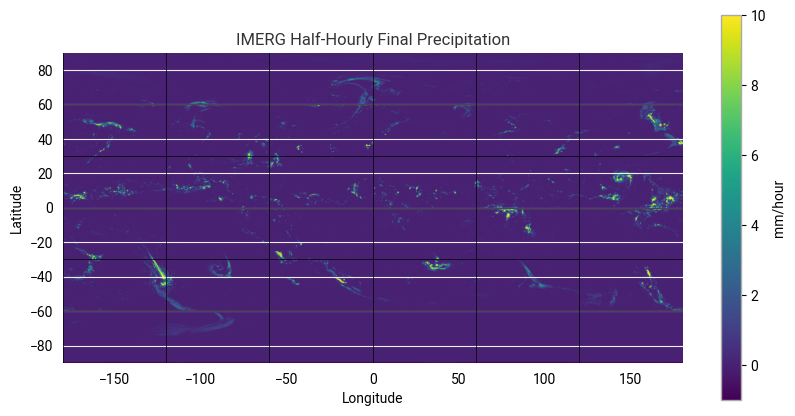

In [46]:

# 3. Extract precipitation data
# For half-hour files in Version 6, use 'precipitationCal'; in Version 7, use 'precipitation'
precip = data['/Grid/precipitation'][:]  # adjust key if needed

# 4. Process the array: remove extra dimension, transpose, and flip vertically
precip = np.flip(precip[0, :, :].transpose(), axis=0)

# 5. Plot the data
plt.figure(figsize=(10, 5))
plt.imshow(precip, vmin=-1, vmax=10, extent=[-180, 180, -90, 90])
cbar = plt.colorbar()
cbar.set_label('mm/hour')
plt.title('IMERG Half-Hourly Final Precipitation')
# Add lat/lon grid lines
for lon in np.arange(-180, 181, 60):
    plt.plot([lon, lon], [-90, 90], color='black', linewidth=0.5)
for lat in np.arange(-60, 61, 30):
    plt.plot([-180, 180], [lat, lat], color='black', linewidth=0.5)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()


In [15]:
for i, fname in enumerate(tqdm(files)):
    try:
        ds = xr.open_dataset(fname)
        old_lats = ds['lat'].values
        old_lons = ds['lon'].values
        new_lats = np.arange(-90.0, 90.0 + 1e-8, target_resolution)
        new_lats = np.flip(new_lats)
        new_lons = np.arange(-180.0, 180.0 + 1e-8, target_resolution)
        ds_interp = ds.interp({'lat': new_lats, 'lon': new_lons}, 
                                method='linear',
                                kwargs={'fill_value': None})
    except OSError as ose:
        print(f"Error opening file {fname}: {ose}")
        continue
    except ValueError as ve:
        print(f"Error processing file {fname}: {ve}")
        continue
    try:
        ds_subset = ds_interp[['precipitation', 'randomError']]
    except KeyError as ke:
        raise KeyError(f"File {fname} is missing one of the required variables: {ke}")
    
    if combined_year is None:
        combined_year = ds_subset
    else:
        combined_year = xr.concat([combined_year, ds_subset], dim='time')

  0%|          | 0/366 [00:00<?, ?it/s]

Error processing file /Datastorage/saptarishi.dhanuka_asp25/imerg_data/3B-DAY.MS.MRG.3IMERG.20121225-S000000-E235959.V07B.nc4: did not find a match in any of xarray's currently installed IO backends ['netcdf4', 'h5netcdf', 'scipy', 'cfgrib', 'earthkit', 'zarr']. Consider explicitly selecting one of the installed engines via the ``engine`` parameter, or installing additional IO dependencies, see:
https://docs.xarray.dev/en/stable/getting-started-guide/installing.html
https://docs.xarray.dev/en/stable/user-guide/io.html
Error processing file /Datastorage/saptarishi.dhanuka_asp25/imerg_data/3B-DAY.MS.MRG.3IMERG.20121226-S000000-E235959.V07B.nc4: did not find a match in any of xarray's currently installed IO backends ['netcdf4', 'h5netcdf', 'scipy', 'cfgrib', 'earthkit', 'zarr']. Consider explicitly selecting one of the installed engines via the ``engine`` parameter, or installing additional IO dependencies, see:
https://docs.xarray.dev/en/stable/getting-started-guide/installing.html
https

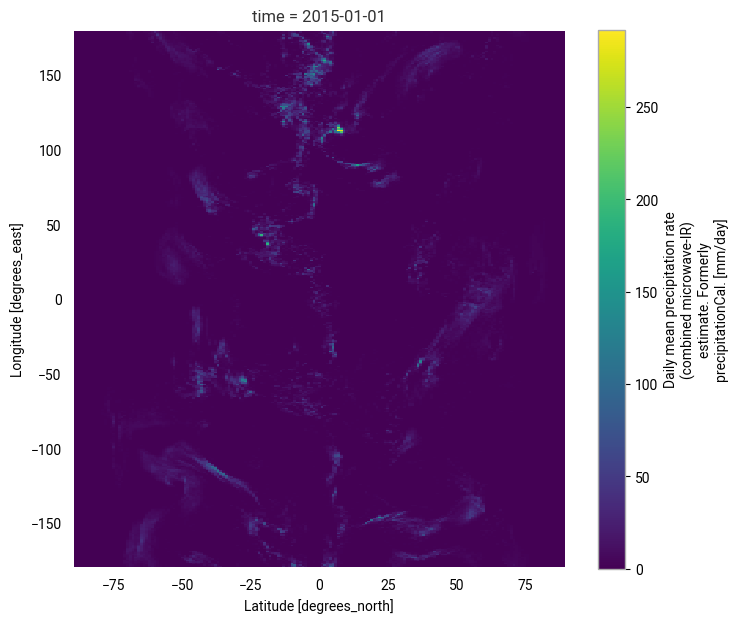

In [ ]:
combined_year.isel(time=0)['precipitation'].plot()

In [16]:
combined_year.nbytes / 1e9

0.379507768

In [17]:
combined_year.time

<xarray.DataArray 'time' (time: 363)> Size: 3kB
array(['2012-01-01T00:00:00.000000000', '2012-01-02T00:00:00.000000000',
       '2012-01-03T00:00:00.000000000', ..., '2012-12-29T00:00:00.000000000',
       '2012-12-30T00:00:00.000000000', '2012-12-31T00:00:00.000000000'],
      shape=(363,), dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 3kB 2012-01-01 2012-01-02 ... 2012-12-31
Attributes:
    standard_name:  time
    long_name:      time
    bounds:         time_bnds

In [ ]:
combined_year.to_netcdf(f"/Datastorage/saptarishi.dhanuka_asp25/imerg_data/combined_imerg_dir/combined{year}_imerg1deg.nc", compute=True)

In [18]:
combined_year.to_netcdf(f"/Datastorage/saptarishi.dhanuka_asp25/imerg_data/combined_imerg_dir/combined_imerg_{year}0101_{year}1231.nc4", compute=True)